# 산학프로젝트
**제조 공정 품질 불량 예측**

# 07_2_WalkForward_Validation

- 시간순 순차 재학습(walk-forward)으로 운영 조건 성능 측정
- 평가 프로토콜: 행을 생산시각 순으로 놓고 각 블록을 직전까지의 데이터로만 학습해 예측, 미래 정보 미사용
- 주의: 04_6의 무작위 CV(AP 0.3931)는 상한이며 이 노트북 수치가 운영 조건

## import

In [1]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT=Path.cwd().parent if Path.cwd().name=='data' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 그래프 한글 표시
plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False

## 경로설정

In [2]:
if Path.cwd().name!='data':
    os.chdir('data')

## 데이터 전처리

- 03 ~ 04_6과 같은 순서로 구성
- 생산시각은 모델 입력에서 빼고 분할 기준으로만 사용

In [3]:
# 02_EDA에서 저장한 전처리 데이터
model_data=pd.read_csv('labeled_modeling.csv', index_col=0)

# 분할 기준으로만 쓰는 생산시각
time_stamp=pd.to_datetime(model_data['TimeStamp'])

# 식별 컬럼 제외
drop_columns=['TimeStamp', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL', 'PART_NAME', 'EQUIP_CD']

final_df=model_data.drop(columns=drop_columns)

X_part=final_df.drop(columns='PassOrFail')
Y=final_df['PassOrFail']

# 라이블링 처리
X_part=pd.get_dummies(data=X_part, columns=['Part'], drop_first=True, dtype=int)

print(f'전체: {X_part.shape}, 불량 수: {Y.sum()}')

전체: (5230, 26), 불량 수: 60


## 1. 시간순 정렬과 에피소드

- 원본 행 순서가 생산시각 순이 아니므로 먼저 정렬
- 에피소드는 07_1과 같은 기준(불량 간격 4시간 초과)으로 구분

In [4]:
sort_index=time_stamp.sort_values(kind='mergesort').index

X_sorted=X_part.loc[sort_index]
Y_sorted=Y.loc[sort_index]
time_sorted=time_stamp.loc[sort_index]

EPISODE_GAP_HOURS=4
defect_time=time_sorted[Y_sorted==1]
episode_id=pd.Series(-1, index=sort_index, dtype=int)
episode_id.loc[defect_time.index]=(defect_time.diff()>pd.Timedelta(hours=EPISODE_GAP_HOURS)).cumsum().to_numpy()

print(f'기간 {time_sorted.min()} ~ {time_sorted.max()}')
print(f'생산일 {time_sorted.dt.date.nunique()}일, 에피소드 {episode_id[episode_id>=0].nunique()}개')

기간 2020-10-16 04:57:47 ~ 2020-11-06 04:27:38
생산일 13일, 에피소드 6개


## 2. Walk-forward 평가

- 모델은 04_6과 같은 RandomForest Balanced, 블록 안에서 재튜닝 없음
- 블록마다 그 직전까지의 행으로 학습하고 그 블록을 예측
- 학습 부분에 불량 2건 미만이면 예측하지 않음
- 첫 에피소드는 구조상 평가 대상에서 빠짐
- 재학습 주기를 바꿔가며 예측 지평의 영향을 확인
- 예측 지평: 마지막 검사 결과가 들어온 시점부터 예측 시점까지의 거리

In [5]:
MIN_TRAIN_DEFECTS=2

model=Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_split=2, min_samples_leaf=4,
                                  class_weight='balanced', n_jobs=-1, random_state=0)),
])


def walk_forward(block_ids):
    proba=pd.Series(np.nan, index=sort_index)
    n_fit=0
    for block in pd.unique(block_ids):
        test_pos=np.where(block_ids==block)[0]
        train_pos=np.arange(test_pos[0])
        if len(train_pos)==0 or Y_sorted.iloc[train_pos].sum()<MIN_TRAIN_DEFECTS:
            continue
        estimator=clone(model).fit(X_sorted.iloc[train_pos], Y_sorted.iloc[train_pos])
        proba.iloc[test_pos]=estimator.predict_proba(X_sorted.iloc[test_pos])[:, 1]
        n_fit+=1
    return proba, n_fit


block_sizes=[10, 25, 50, 100, 250, 500]

wf_proba={}
fit_counts={}
for block_size in block_sizes:
    start=time.time()
    wf_proba[f'{block_size}샷'], fit_counts[f'{block_size}샷']=walk_forward(np.arange(len(X_sorted))//block_size)
    print(f'{block_size}샷 블록: 재학습 {fit_counts[f"{block_size}샷"]}회, {time.time()-start:.0f}초')

start=time.time()
wf_proba['생산일'], fit_counts['생산일']=walk_forward(pd.factorize(time_sorted.dt.date)[0])
print(f'생산일 블록: 재학습 {fit_counts["생산일"]}회, {time.time()-start:.0f}초')

wf_df=pd.DataFrame(wf_proba)

10샷 블록: 재학습 514회, 299초


25샷 블록: 재학습 206회, 123초


50샷 블록: 재학습 103회, 58초


100샷 블록: 재학습 52회, 31초


250샷 블록: 재학습 20회, 11초


500샷 블록: 재학습 10회, 6초


생산일 블록: 재학습 12회, 7초


## 3. 비교군: 같은 행에 대한 무작위 CV 확률

- 04_6이 저장한 OOF 확률을 같은 행 순서로 결합
- 모델과 데이터가 같으므로 차이는 전부 학습에 미래 정보를 넣었는지 여부에서 발생

In [6]:
oof_proba=pd.read_csv('04_6_AutoEncoder_CV_Validation_oof_proba.csv', index_col=0)
assert (oof_proba['PassOrFail'].loc[Y.index].to_numpy()==Y.to_numpy()).all(), '행 정렬이 04_6과 다릅니다'

repeat_columns=[f'RandomForest Balanced | 원본 | rep{r}' for r in [1, 2, 3]]
cv_df=oof_proba.loc[sort_index, repeat_columns]
print(f'무작위 CV 확률 {cv_df.shape[0]}행 × 반복 {cv_df.shape[1]}회')

무작위 CV 확률 5230행 × 반복 3회


## 4. 재학습 주기별 성능

- 블록 시간은 한 블록이 덮는 실제 생산 시간의 중앙값이며 이 값이 곧 예측 지평
- 평가 행 수가 주기마다 다르므로 여기서는 각자의 평가 행 기준
- 공통 행 기준 비교는 5절에서 수행

In [7]:
def score(proba, y, episode, ratio=0.10):
    mask=proba.notna()
    y_eval, p_eval=y[mask], proba[mask]
    k=int(round(len(y_eval)*ratio))
    cut=np.sort(p_eval.to_numpy())[::-1][k-1]
    selected=p_eval>=cut
    episode_eval=episode[mask]
    hits=sum(bool(selected[episode_eval==e].any()) for e in sorted(episode_eval[episode_eval>=0].unique()))
    n_episode=episode_eval[episode_eval>=0].nunique()
    base=y_eval.mean()
    ap=average_precision_score(y_eval, p_eval)
    return {
        '평가 행': int(mask.sum()),
        '평가 불량': int(y_eval.sum()),
        'AP': round(ap, 4),
        'AP 기저 대비': round(ap/base, 1),
        'Recall@10%': round(((selected) & (y_eval==1)).sum()/y_eval.sum(), 3),
        '에피소드 감지': f'{hits}/{n_episode}',
    }


horizon_rows=[]
for name in wf_df.columns:
    proba=wf_df[name]
    mask=proba.notna()
    if name=='생산일':
        block_minutes=np.nan
    else:
        block_size=int(name.replace('샷', ''))
        block_ids=(np.arange(len(X_sorted))//block_size)[mask.to_numpy()]
        spans=[(time_sorted[mask].iloc[pos].max()-time_sorted[mask].iloc[pos].min()).total_seconds()/60
               for pos in [np.where(block_ids==b)[0] for b in np.unique(block_ids)] if len(pos)>1]
        block_minutes=round(np.median(spans))
    horizon_rows.append({'재학습 주기': name, '재학습 횟수': fit_counts[name],
                         '블록 시간(분)': block_minutes, **score(proba, Y_sorted, episode_id)})

horizon_df=pd.DataFrame(horizon_rows)
horizon_df

,재학습 주기,재학습 횟수,블록 시간(분),평가 행,평가 불량,AP,AP 기저 대비,Recall@10%,에피소드 감지
0,10샷,514,5.0,5140,58,0.0926,8.2,0.517,5/6
1,25샷,206,12.0,5130,56,0.0634,5.8,0.500,5/6
2,50샷,103,25.0,5130,56,0.0657,6.0,0.500,5/6
3,100샷,52,51.0,5130,56,0.0349,3.2,0.446,5/6
4,250샷,20,197.0,4980,43,0.0241,2.8,0.395,4/5
5,500샷,10,2089.0,4730,43,0.0356,3.9,0.442,4/5
6,생산일,12,NaN,4855,43,0.0145,1.6,0.209,3/5


## 5. 공통 평가 행에서의 비교

- 모든 프로토콜이 공통으로 예측한 행만 남겨 같은 분모에서 비교
- 무작위 CV는 반복 3회 평균으로 기재

In [8]:
common_mask=wf_df.notna().all(axis=1)
print(f'공통 평가 행 {common_mask.sum()}건, 불량 {int(Y_sorted[common_mask].sum())}건')

common_rows=[]
for name in wf_df.columns:
    common_rows.append({'프로토콜': f'Walk-forward {name} 재학습',
                        **score(wf_df[name].where(common_mask), Y_sorted, episode_id)})

cv_scores=[score(cv_df[column].where(common_mask), Y_sorted, episode_id) for column in repeat_columns]
common_rows.append({
    '프로토콜': '[상한] 무작위 CV (04_6, 반복 3회 평균)',
    '평가 행': cv_scores[0]['평가 행'],
    '평가 불량': cv_scores[0]['평가 불량'],
    'AP': round(np.mean([s['AP'] for s in cv_scores]), 4),
    'AP 기저 대비': round(np.mean([s['AP 기저 대비'] for s in cv_scores]), 1),
    'Recall@10%': round(np.mean([s['Recall@10%'] for s in cv_scores]), 3),
    '에피소드 감지': cv_scores[0]['에피소드 감지'],
})

common_df=pd.DataFrame(common_rows)
common_df

공통 평가 행 4730건, 불량 43건


,프로토콜,평가 행,평가 불량,AP,AP 기저 대비,Recall@10%,에피소드 감지
0,Walk-forward 10샷 재학습,4730,43,0.0710,7.8,0.581,4/5
1,Walk-forward 25샷 재학습,4730,43,0.0743,8.2,0.581,4/5
2,Walk-forward 50샷 재학습,4730,43,0.0776,8.5,0.628,4/5
3,Walk-forward 100샷 재학습,4730,43,0.0365,4.0,0.488,4/5
4,Walk-forward 250샷 재학습,4730,43,0.0366,4.0,0.442,4/5
5,Walk-forward 500샷 재학습,4730,43,0.0356,3.9,0.442,4/5
6,Walk-forward 생산일 재학습,4730,43,0.0242,2.7,0.209,3/5
7,"[상한] 무작위 CV (04_6, 반복 3회 평균)",4730,43,0.3540,38.9,0.752,4/5


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


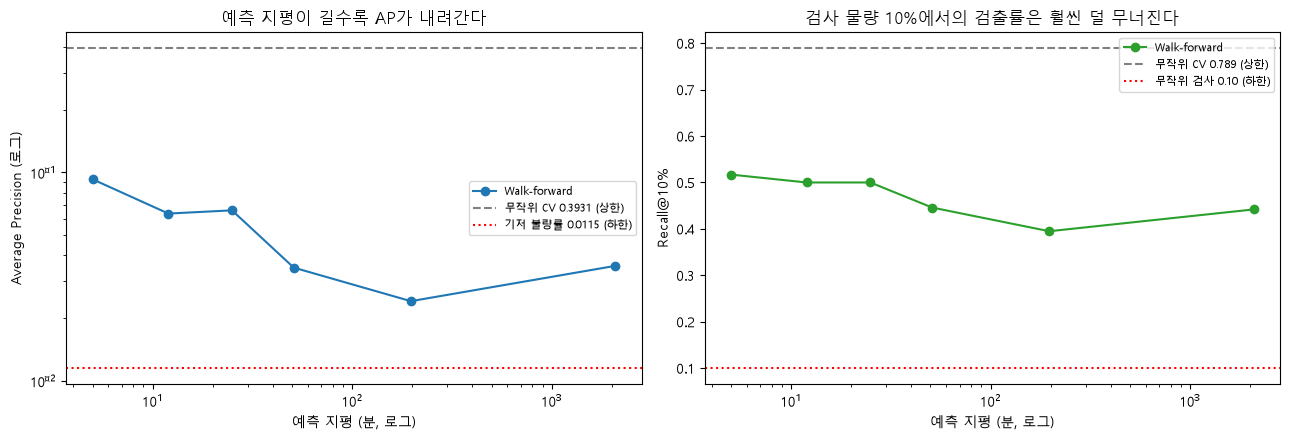

In [9]:
fig, axes=plt.subplots(1, 2, figsize=(13, 4.5))

plot_df=horizon_df[horizon_df['재학습 주기']!='생산일']
x=plot_df['블록 시간(분)']

axes[0].plot(x, plot_df['AP'], marker='o', label='Walk-forward')
axes[0].axhline(0.3931, color='gray', linestyle='--', label='무작위 CV 0.3931 (상한)')
axes[0].axhline(0.0115, color='red', linestyle=':', label='기저 불량률 0.0115 (하한)')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('예측 지평 (분, 로그)')
axes[0].set_ylabel('Average Precision (로그)')
axes[0].set_title('예측 지평이 길수록 AP가 내려간다')
axes[0].legend(fontsize=8)

axes[1].plot(x, plot_df['Recall@10%'], marker='o', color='tab:green', label='Walk-forward')
axes[1].axhline(0.789, color='gray', linestyle='--', label='무작위 CV 0.789 (상한)')
axes[1].axhline(0.10, color='red', linestyle=':', label='무작위 검사 0.10 (하한)')
axes[1].set_xscale('log')
axes[1].set_xlabel('예측 지평 (분, 로그)')
axes[1].set_ylabel('Recall@10%')
axes[1].set_title('검사 물량 10%에서의 검출률은 훨씬 덜 무너진다')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. 정리

**AP는 프로토콜에 매우 민감**
- 무작위 CV 0.3540이 순차 재학습에서 0.0242 ~ 0.0776으로 하락
- 04_6의 AP는 상한으로 해석

**재학습 주기를 줄이면 효과 있음**
- 재학습 주기를 하루에서 25분으로 줄이면 Recall@10%가 0.209 → 0.628

**단, 무작위 CV 수준에는 도달하지 못함**
- 5분 주기에서도 AP 0.0710으로 상한의 1/5
- 무작위 CV는 같은 10분 구간의 다른 샷을 학습에 넣은 조건이라 순차 재학습으로 재현 불가

**운영 지표는 AP보다 잘 버팀**
- Recall@10% 0.752 → 0.628, 에피소드 감지는 4/5로 동일
- 재학습 주기 5분·12분·25분 사이 차이는 노이즈 범위
- 의미 있는 구분은 25분 이내 / 1시간 ~ 35시간 / 하루 세 구간

**보고 시 04_6 AP는 상한, 이 노트북 수치는 운영 조건으로 병기**

In [10]:
horizon_df.to_csv('07_2_WalkForward_horizon.csv', index=False, encoding='utf-8-sig')
common_df.to_csv('07_2_WalkForward_common.csv', index=False, encoding='utf-8-sig')

wf_save=wf_df.copy()
wf_save.insert(0, 'Episode', episode_id)
wf_save.insert(0, 'PassOrFail', Y_sorted)
wf_save.insert(0, 'TimeStamp', time_sorted)
wf_save.to_csv('07_2_WalkForward_proba.csv', encoding='utf-8-sig')
print('저장 완료')

저장 완료
